# Perceptron model for Binary Classification

The goal is to implement and understand the Perceptron model for binary classification.

## Part (a): Implementation of the Perceptron Model


### 1. Perceptron Algorithm

The Perceptron is a linear classifier that predicts based on a weighted sum of input features. It updates weights using the formula:
$𝑤_{𝑖} = 𝑤_{𝑖} + η(𝑦 − 𝑦')𝑥_{𝑖}$ where $𝑤_{𝑖}$ ​is the weight, η is the learning rate, 𝑦 is the true label, 𝑦' is the predicted label, and $x_{𝑖}$ is the input feature.



### 2. Dataset Preparation & Data Preprocessing:

- Use the Iris dataset, selecting only two classes: `Setosa` and `Versicolor`. Use two features: `Sepal Length` and `Petal Length`. 
- Load the dataset, select the relevant classes and features, and standardize the data `(mean = 0, variance = 1)`.

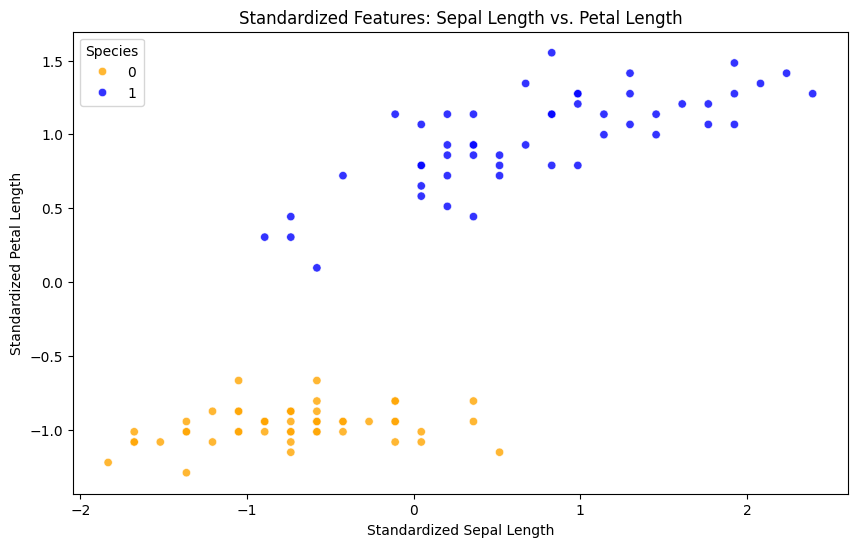

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split

iris_df = pd.read_csv("./Iris.csv")
iris_df.drop("Id", axis=1, inplace=True)
iris_filtered = iris_df[iris_df["Species"].isin(["Iris-setosa", "Iris-versicolor"])]
iris_filtered = iris_filtered[["SepalLengthCm", "PetalLengthCm", "Species"]]
iris_filtered["Species"] = iris_filtered["Species"].map(
    {"Iris-setosa": 0, "Iris-versicolor": 1}
)
X = iris_filtered[["SepalLengthCm", "PetalLengthCm"]].values
Y = iris_filtered["Species"].values

# from sklearn.datasets import load_iris
# iris = load_iris()
# X = iris.data
# Y = iris.target

# # Select only Setosa and Versicolor (labels 0 and 1) and features sepal length and petal length
# mask = Y < 2
# X = X[mask][:, [0, 2]]  # Sepal length and petal length
# Y = Y[mask]

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Data Analysis - Sepal Length VS Petal Length
plot_df = pd.DataFrame(
    X_standardized, columns=["Standardized Sepal Length", "Standardized Petal Length"]
)
plot_df["Species"] = Y
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Standardized Sepal Length",
    y="Standardized Petal Length",
    hue="Species",
    palette={0: "orange", 1: "blue"}, # "Iris-setosa": 0, "Iris-versicolor": 1
    alpha=0.8,
)
plt.title("Standardized Features: Sepal Length vs. Petal Length")
plt.xlabel("Standardized Sepal Length")
plt.ylabel("Standardized Petal Length")
plt.show()

### 3. Implementation of the Perceptron Model

- Implement a Perceptron class with methods for:
  
  - Initialization (`__init__`)
  - Training (`fit`)
  - Prediction (`predict`)
  
- Include parameters for `learning rate`, `number of epochs`, and `random state` for
reproducibility.

In [247]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000, random_state=None):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.accuracy_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Shuffle indices based on random state
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        weight_changes = []
        for epoch in range(self.n_iters):
            total_weight_change = 0
            for idx in indices:
                x_i = X[idx]
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self._activation(linear_output)
                update = self.learning_rate * (y[idx] - y_predicted)
                weight_change = update * x_i
                total_weight_change += np.linalg.norm(weight_change)
                self.weights += weight_change
                self.bias += update
            weight_changes.append(total_weight_change)
            y_pred_epoch = self.predict(X)
            accuracy = np.sum(y_pred_epoch == y) / len(y)
            self.accuracy_history.append(accuracy)
            print(f"Epoch {epoch + 1}, Total Weight Change: {total_weight_change}")
            if total_weight_change < 1e-5:
                print("Early stopping due to convergence")
                break
        return weight_changes

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._activation(linear_output)

    def _activation(self, x):
        return np.where(x >= 0, 1, 0)

    def score(self, X, y):
        # Calculate accuracy
        y_pred = self.predict(X)
        return np.sum(y_pred == y) / len(y)

    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "n_iters": self.n_iters,
            "random_state": self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

### 4. Training the Perceptron Model

- Split the dataset into training `(80%)` and testing `(20%)` sets.
- Train your `Perceptron` using the `training data`.

In [248]:
def split_dataset(X, Y, test_size=0.2):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    split_index = int(len(X) * (1 - test_size))
    X_train = X[indices[:split_index]]
    Y_train = Y[indices[:split_index]]
    X_test = X[indices[split_index:]]
    Y_test = Y[indices[split_index:]]
    return X_train, X_test, Y_train, Y_test

X_train, X_test, Y_train, Y_test = split_dataset(X_standardized, Y, test_size=0.2)

unique, counts = np.unique(Y_train, return_counts=True)
train_class_distribution = dict(zip(unique, counts))
print("Training Class Distribution:", train_class_distribution)

unique_test, counts_test = np.unique(Y_test, return_counts=True)
test_class_distribution = dict(zip(unique_test, counts_test))
print("Testing Class Distribution:", test_class_distribution)

Training Class Distribution: {np.int64(0): np.int64(40), np.int64(1): np.int64(40)}
Testing Class Distribution: {np.int64(0): np.int64(10), np.int64(1): np.int64(10)}


## Part (b): Evaluation and Visualization of the Perceptron Model

### 1. Model Evaluation:

- Use your trained Perceptron model to make predictions on the test set.
- Calculate and report the model's `accuracy` metric.

In [249]:
# Training and Testing the Perceptron model
perceptron = Perceptron(learning_rate=0.01, n_iters=1000, random_state=42)
perceptron.fit(X_train, Y_train)
Y_pred = perceptron.predict(X_test)

def check_sklearn_perceptron_modal():
    X_train, X_test, y_train, y_test = train_test_split(
        X_standardized, Y, test_size=0.2, random_state=42
    )
    sklearn_perceptron = SklearnPerceptron(
        max_iter=1000, eta0=0.01, random_state=42, tol=1e-3
    )
    sklearn_perceptron.fit(X_train, y_train)
    y_pred_sklearn = sklearn_perceptron.predict(X_test)
    accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
    print(f"Sklearn Perceptron Accuracy: {accuracy_sklearn * 100:.2f}%")

def confusion_matrix_manual(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    TP = np.sum((actual == 1) & (predicted == 1))  # True Positives
    TN = np.sum((actual == 0) & (predicted == 0))  # True Negatives
    FP = np.sum((actual == 0) & (predicted == 1))  # False Positives
    FN = np.sum((actual == 1) & (predicted == 0))  # False Negatives
    return TP, TN, FP, FN

def precision_recall_f1(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0
    )
    return precision, recall, f1

# Calculate metrics
accuracy = np.sum(Y_pred == Y_test) / len(Y_test)
TP, TN, FP, FN = confusion_matrix_manual(Y_test, Y_pred)
precision, recall, f1 = precision_recall_f1(TP, FP, FN)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("Manual Confusion Matrix:\n", f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

check_sklearn_perceptron_modal()

# Using cross-validation helps ensure that your model generalizes well. Here’s how you can implement it:
# Create a Perceptron instance for cross-validation
perceptron_cv = Perceptron(learning_rate=0.01, n_iters=1000, random_state=42)

# Perform cross-validation
cross_val_scores = cross_val_score(
    perceptron_cv, X_standardized, Y, cv=5
)  # 5-fold CV
print(f"Cross-Validation Scores: {cross_val_scores}")
print(f"Mean Cross-Validation Score: {np.mean(cross_val_scores):.2f}")

Epoch 1, Total Weight Change: 0.0447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Manual Confusion Matrix:
 TP: 10, TN: 10, FP: 0, FN: 0
Sklearn Perceptron Accuracy: 100.00%
Epoch 1, Total Weight Change: 0.01881903252161128
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence
Epoch 1, Total Weight Change: 0.027148162238357653
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence
Epoch 1, Total Weight Change: 0.03233776104208007
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence
Epoch 1, Total Weight Change: 0.03233776104208007
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence
Epoch 1, Total Weight Change: 0.02862877540142171
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence
Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean Cross-Validation Score: 1.00


### 2. Model Visualization:

- Plot the decision boundary learned by your Perceptron model.
- Visualize the data points (training and test) with different colors for different
classes.
- Display a plot showing how the accuracy changes over each epoch during
training.

In [250]:
# 3. Visualize the Decision Boundary
# Visualizing the decision boundary can give you insights into how well the model separates the two classes. Here’s how to do it:
def plot_decision_boundary(perceptron, X_train, Y_train, X_test, Y_test):
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    scatter_train = plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=Y_train,
        edgecolors="k",
        marker="o",
        label="Training Data",
        s=100,
    )
    scatter_test = plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=Y_test,
        edgecolors="k",
        marker="s",
        label="Test Data",
        s=100,
    )
    plt.xlabel("Sepal Length (standardized)")
    plt.ylabel("Petal Length (standardized)")
    plt.title('Decision Boundary of Perceptron')
    plt.legend(handles=[scatter_train, scatter_test])
    plt.show()

def plot_accuracy_over_epochs(perceptron):
    plt.figure(figsize=(10, 6))
    plt.plot(perceptron.accuracy_history, color="blue")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.show()

def plot_weight_change_over_time(weight_changes):
    if weight_changes is None or len(weight_changes) == 0:
      print("No weight changes recorded. Skipping plot.")
      return
    plt.plot(weight_changes)
    plt.title("Weight Changes Over Time")
    plt.xlabel("Iterations")
    plt.ylabel("Magnitude of Weight Change")
    plt.show()

# plot_decision_boundary(perceptron, X_train, Y_train, X_test, Y_test)
# plot_accuracy_over_epochs(perceptron)


# # 4. Experiment with Hyperparameters
# # You can test different values for learning_rate and n_iters:
# # Experiment with different learning rates and iterations
random_state = 42
learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9]
epoch_values = [500, 1000, 1500]

results = []
for lr in learning_rates:
    for epochs in epoch_values:
        print(f"\nTraining with learning rate={lr} and epochs={epochs}")
        perceptron = Perceptron(
            learning_rate=lr, n_iters=epochs, random_state=random_state
        )
        weight_changes = perceptron.fit(X_train, Y_train)
        y_test_pred = perceptron.predict(X_test)
        test_accuracy = np.mean(Y_test == y_test_pred)
        results.append(
            {
                "learning_rates": lr,
                "epochs": epochs,
                "accuracy": f"{test_accuracy * 100:.2f}%"
                # "execution_time": f"{execution_time:.4f} seconds",
                # "precision": f"{precision * 100:.2f}%",
                # "recall": f"{recall * 100:.2f}%",
                # "f1": f"{f1 * 100:.2f}%",
            }
        )
        # plot_weight_change_over_time(weight_changes)
        # plot_decision_boundary(perceptron, X_train, Y_train, X_test, Y_test)
        # plot_accuracy_over_epochs(perceptron)


print(results)
# for learning_rate in [0.001, 0.01, 0.1]:
#     for n_iters in [500, 1000, 1500]:
#         perceptron_test = Perceptron(
#             learning_rate=learning_rate, n_iters=n_iters, randomState=42
#         )
#         perceptron_test.fit(X_train, Y_test_numeric)
#         y_pred_test = perceptron_test.predict(X_test)
#         accuracy = np.sum(y_pred_test == Y_test_numeric) / len(Y_test_numeric)
#         print(
#             f"Learning Rate: {learning_rate}, N Iterations: {n_iters}, Accuracy: {accuracy:.2f}"
#         )

# 5. Compare with Other Models
# You can use scikit-learn to implement and compare your Perceptron with Logistic Regression and Support Vector Machine (SVM):

# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC

# # Logistic Regression
# logistic_model = LogisticRegression()
# logistic_model.fit(X_train, Y_train)
# logistic_pred = logistic_model.predict(X_test)
# logistic_accuracy = np.sum(logistic_pred == Y_test_numeric) / len(Y_test_numeric)

# # SVM
# svm_model = SVC()
# svm_model.fit(X_train, Y_train)
# svm_pred = svm_model.predict(X_test)
# svm_accuracy = np.sum(svm_pred == Y_test_numeric) / len(Y_test_numeric)

# print(f"Logistic Regression Accuracy: {logistic_accuracy:.2f}")
# print(f"SVM Accuracy: {svm_accuracy:.2f}")


Training with learning rate=0.001 and epochs=500
Epoch 1, Total Weight Change: 0.00447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence

Training with learning rate=0.001 and epochs=1000
Epoch 1, Total Weight Change: 0.00447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence

Training with learning rate=0.001 and epochs=1500
Epoch 1, Total Weight Change: 0.00447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence

Training with learning rate=0.01 and epochs=500
Epoch 1, Total Weight Change: 0.0447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence

Training with learning rate=0.01 and epochs=1000
Epoch 1, Total Weight Change: 0.0447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to convergence

Training with learning rate=0.01 and epochs=1500
Epoch 1, Total Weight Change: 0.0447429818327893
Epoch 2, Total Weight Change: 0.0
Early stopping due to conver